# Bacterial Mutation Timeline Predictor
## CNN-LSTM Deep Learning Model — AMR Evolution Forecasting

### What This Model Does
Given a bacterial genome sequence and an antibiotic, the model:
1. **Predicts which positions in the genome will mutate** under drug pressure
2. **Identifies which nucleotide (A/T/C/G) each site will evolve to**
3. **Simulates a week-by-week resistance timeline** — e.g. *'After 3 weeks: 40% resistant, after 6 weeks: structure fails'*

### Features Used From Your CSV
| Column | Role |
|---|---|
| `Antibiotic` | Stress condition the bacteria evolves under |
| `Resistant Phenotype` | Training label: Susceptible=0.0, Intermediate=0.5, Resistant=1.0 |
| `Measurement Value` | Continuous resistance intensity (MIC mg/L or zone mm) |
| `Measurement Unit` | Determines how to interpret measurement (MIC vs disk diffusion) |
| `fasta_path` | Links each genome to its DNA sequence |

### Architecture
```
DNA k-mer window
  → Embedding(64) → Conv1D(128,5) → Conv1D(64,3) → BiLSTM(64) → [128-dim]
                                                                         ↘
Antibiotic (one-hot)                                                  Concatenate
  → Dense(32)  ──────────────────────────────────────────────────────────↗
                                                                    Dense(128)
                                                               ↙        ↓         ↘
                                                   nucleotide    mutation_prob   resistance
                                                   (4-class)      (sigmoid)      (sigmoid)
                                                   A / T / C / G   0–1 prob       0–1 score
```

## 1. Setup and Imports

In [12]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'biopython', '-q'], check=True)

import numpy as np
import pandas as pd
import os, glob, random
from collections import Counter
from Bio import SeqIO

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


## 2. Configuration
Set all paths and hyperparameters here. Only change `FASTA_BASE_DIR` and `CSV_DIR`.

In [ ]:
from pathlib import Path

FASTA_BASE_DIR = Path(r'C:\Users\HP\OneDrive - Higher Education Commission\Desktop\FYP1\sample_fasta_output')
CSV_DIR        = Path(r'C:\Users\HP\OneDrive - Higher Education Commission\Desktop\FYP1\sample_mapped_output')

# ── Sequence Encoding ────────────────────────────────────────────────────
WINDOW_SIZE        = 50
K_MER_SIZE         = 3
MAX_VOCAB          = 500
SAMPLES_PER_GENOME = 1500
MUT_OVERSAMPLE     = 4
MAX_SEQ_LEN        = 200_000   # cap genome length – avoids multi-GB consensus arrays

# ── Model Hyperparameters ────────────────────────────────────────────────
EMBED_DIM     = 64
LSTM_UNITS    = 64
BATCH_SIZE    = 128
EPOCHS        = 3
LEARNING_RATE = 0.001
N_WORKERS     = 4

# ── Timeline Simulation ──────────────────────────────────────────────────
N_WEEKS              = 8
MUTATIONS_PER_WEEK   = 30
RESISTANCE_THRESHOLD = 0.80

# ── Resistance Labels ────────────────────────────────────────────────────
PHENOTYPE_SCORE = {'Susceptible': 0.0, 'Intermediate': 0.5, 'Resistant': 1.0}
NUCLEOTIDES     = ['A', 'T', 'C', 'G']
NUC_TO_IDX      = {n: i for i, n in enumerate(NUCLEOTIDES)}
IDX_TO_NUC      = {i: n for i, n in enumerate(NUCLEOTIDES)}

# Fast ASCII lookup: ord('A')=0, ord('T')=1, ord('C')=2, ord('G')=3, other=4
_NUC_LOOKUP = np.full(256, 4, dtype=np.uint8)
for _i, _n in enumerate('ATCG'):
    _NUC_LOOKUP[ord(_n)] = _i

# Non-ATCG strip table
_STRIP = str.maketrans('', '', ''.join(
    c for c in map(chr, range(256)) if c not in 'ATCG'
))

print('Configuration loaded.')
print(f'  Max sequence length : {MAX_SEQ_LEN:,} bp')
print(f'  Window size         : {WINDOW_SIZE} bp')
print(f'  K-mer size          : {K_MER_SIZE}')
print(f'  Samples per genome  : {SAMPLES_PER_GENOME}')


Configuration loaded.
  Max sequence length : 200,000 bp
  Window size         : 50 bp
  K-mer size          : 3
  Samples per genome  : 1500


## 3. Load All CSV Files + Linked FASTA Sequences
Loads every mapped CSV in your folder, resolves Windows-style `fasta_path` to Colab paths,
and reads the corresponding DNA sequence from the FASTA file.

In [14]:
def resolve_fasta_path(windows_path, fasta_base_dir):
    norm  = str(windows_path).replace('\\', '/')
    parts = norm.split('/')
    try:
        idx      = next(i for i, p in enumerate(parts) if p == 'fasta_output')
        relative = '/'.join(parts[idx + 1:])
    except StopIteration:
        relative = '/'.join(parts[-2:])
    return os.path.join(fasta_base_dir, relative)


def _read_fasta_capped(path, max_len=MAX_SEQ_LEN):
    """Read multi-contig FASTA, cap at max_len bp, return ATCG-only string."""
    chunks = []
    total  = 0
    with open(path, 'r') as f:
        for line in f:
            if line.startswith('>'):
                continue
            chunk = line.strip().upper().translate(_STRIP)
            chunks.append(chunk)
            total += len(chunk)
            if total >= max_len:
                break
    return ''.join(chunks)[:max_len]


def parse_mic_value(val, unit):
    try:
        if isinstance(val, str) and '/' in val:
            val = val.split('/')[0]
        return float(val)
    except (ValueError, TypeError):
        return float('nan')


def load_csv_files(csv_dir):
    csv_files = glob.glob(os.path.join(csv_dir, '*.csv'))
    if not csv_files:
        raise FileNotFoundError(f'No CSV files found in {csv_dir}')
    dfs = []
    for f in csv_files:
        df = pd.read_csv(f)
        df['source_csv'] = os.path.basename(f)
        dfs.append(df)
    combined = pd.concat(dfs, ignore_index=True)
    print(f'Loaded {len(csv_files)} CSV file(s) → {len(combined):,} rows')
    return combined


def load_all_data(csv_dir, fasta_base_dir):
    """
    Load all mapped CSVs, resolve FASTA paths, read sequences capped at
    MAX_SEQ_LEN.  Returns a DataFrame with genome sequences ready for
    consensus building and sample creation.
    """
    df = load_csv_files(csv_dir)
    needed = ['Genome ID', 'Antibiotic', 'Resistant Phenotype', 'fasta_path']
    df = df.dropna(subset=needed).copy()
    df = df[df['Resistant Phenotype'].isin(PHENOTYPE_SCORE)].copy()

    df['mic_value'] = df.apply(
        lambda r: parse_mic_value(r.get('Measurement Value'),
                                  r.get('Measurement Unit')), axis=1
    )
    mask_mm = df['Measurement Unit'] == 'mm'
    df.loc[mask_mm, 'mic_value'] = -df.loc[mask_mm, 'mic_value']

    df['resistance_score'] = df['Resistant Phenotype'].map(PHENOTYPE_SCORE)
    df['colab_fasta']      = df['fasta_path'].apply(
        lambda p: resolve_fasta_path(str(p), fasta_base_dir)
    )

    # ── Read unique FASTA files once (cache by path) ──────────────────
    print('Loading FASTA sequences (capped at {:,} bp)...'.format(MAX_SEQ_LEN))
    seen   = {}
    records = []

    for _, row in df.iterrows():
        path = row['colab_fasta']
        if path not in seen:
            if not os.path.exists(path):
                seen[path] = None
                continue
            try:
                seq = _read_fasta_capped(path, MAX_SEQ_LEN)
                seen[path] = seq if len(seq) >= WINDOW_SIZE + 100 else None
            except Exception as e:
                seen[path] = None

        seq = seen[path]
        if seq is None:
            continue

        records.append({
            'genome_id'       : str(row['Genome ID']),
            'antibiotic'      : row['Antibiotic'],
            'phenotype'       : row['Resistant Phenotype'],
            'resistance_score': float(row['resistance_score']),
            'mic_value'       : float(row['mic_value']) if not pd.isna(row['mic_value']) else 0.0,
            'sequence'        : seq,
            'fasta_file'      : os.path.basename(path)
        })

    result = pd.DataFrame(records)
    print(f'\nFinal dataset     : {len(result):,} genome-antibiotic pairs')
    print(f'Unique genomes    : {result["genome_id"].nunique():,}')
    print(f'Unique antibiotics: {result["antibiotic"].nunique():,}')
    print(f'Phenotype dist    : {result["phenotype"].value_counts().to_dict()}')
    return result


data = load_all_data(CSV_DIR, FASTA_BASE_DIR)


Loaded 1 CSV file(s) → 72 rows
Loading FASTA sequences (capped at 200,000 bp)...



Final dataset     : 44 genome-antibiotic pairs
Unique genomes    : 4
Unique antibiotics: 20
Phenotype dist    : {'Susceptible': 24, 'Resistant': 12, 'Intermediate': 8}


## 4. Encode Antibiotics and Build K-mer Vocabulary
- **Antibiotic** → integer index → stored in lookup table for one-hot encoding
- **DNA sequences** → sliding 3-mer tokens → integer indices

In [15]:
# ── Antibiotic Encoding ─────────────────────────────────────────────────
antibiotic_list = sorted(data['antibiotic'].unique().tolist())
ANTIBIOTIC_TO_IDX = {a: i for i, a in enumerate(antibiotic_list)}
N_ANTIBIOTICS = len(antibiotic_list)

data['antibiotic_idx'] = data['antibiotic'].map(ANTIBIOTIC_TO_IDX)

print(f'Antibiotics ({N_ANTIBIOTICS}): {antibiotic_list}')


# ── K-mer Vocabulary ─────────────────────────────────────────────────────
def generate_kmers(seq, k):
    return [seq[i:i+k] for i in range(len(seq)-k+1)
            if all(c in NUCLEOTIDES for c in seq[i:i+k])]


def build_vocab(sequences, k=K_MER_SIZE, max_vocab=MAX_VOCAB):
    counter = Counter()
    for seq in sequences:
        counter.update(generate_kmers(seq, k))
    top = counter.most_common(max_vocab)
    vocab = {km: i+1 for i, (km, _) in enumerate(top)}
    vocab['<UNK>'] = 0
    return vocab


kmer_vocab = build_vocab(data['sequence'].tolist())
VOCAB_SIZE  = len(kmer_vocab)
SEQ_LEN     = WINDOW_SIZE - K_MER_SIZE + 1   # k-mers per window

print(f'K-mer vocabulary size : {VOCAB_SIZE}')
print(f'K-mers per window     : {SEQ_LEN}')

Antibiotics (20): ['amikacin', 'ampicillin', 'ampicillin/sulbactam', 'carbenicillin', 'cefepime', 'ceftazidime', 'ceftriaxone', 'chloramphenicol', 'ciprofloxacin', 'doxycycline', 'erythromycin', 'gentamicin', 'imipenem', 'levofloxacin', 'meropenem', 'penicillin', 'rifampin', 'tetracycline', 'tobramycin', 'trimethoprim/sulfamethoxazole']
K-mer vocabulary size : 65
K-mers per window     : 48


## 5. Build Consensus Reference and Create Training Samples

### Consensus
One majority-vote consensus is built **per antibiotic** from the Susceptible genomes.
This is the 'unexposed' reference. Any position differing from it = mutation site.

### Training Samples (per position)
| Feature | Shape | Description |
|---|---|---|
| `X_seq` | (N, SEQ_LEN) | k-mer indices of reference window at this position |
| `X_ab` | (N, N_ANTIBIOTICS) | one-hot antibiotic |
| `y_nuc` | (N, 4) | nucleotide at this position (one-hot A/T/C/G) |
| `y_mut` | (N,) | 1=mutated vs susceptible reference, 0=conserved |
| `y_res` | (N,) | resistance_score of this genome (0 / 0.5 / 1.0) |

In [43]:
# ────────────────────────────────────────────────────────────────────────
# Pre-compute k-mer integer → vocab-index lookup table
# ────────────────────────────────────────────────────────────────────────
_KMER_INT_SIZE   = 4 ** K_MER_SIZE
_KMER_INT_TO_VOC = np.zeros(_KMER_INT_SIZE, dtype=np.int32)  # default 0 = UNK
_NUC_VAL         = {'A': 0, 'T': 1, 'C': 2, 'G': 3}

for _km, _vid in kmer_vocab.items():
    if _km.startswith('<') or any(c not in _NUC_VAL for c in _km):
        continue
    _int = sum(_NUC_VAL[c] * (4 ** i) for i, c in enumerate(reversed(_km)))
    _KMER_INT_TO_VOC[_int] = _vid


def _seq_to_int(seq):
    """DNA string → uint8 numpy array (A=0 T=1 C=2 G=3 other=4). Vectorised O(L)."""
    return _NUC_LOOKUP[np.frombuffer(
        seq.encode('ascii', errors='replace'), dtype=np.uint8
    )]


def _int_to_kmer_ids(seq_int, k=K_MER_SIZE):
    """
    Nucleotide-int array → vocab-index array. Vectorised O(L*k) numpy.
    Positions with any invalid nucleotide (value=4) → UNK (0).
    """
    n = len(seq_int)
    if n < k:
        return np.array([], dtype=np.int32)
    weights   = 4 ** np.arange(k - 1, -1, -1, dtype=np.int64)
    kmer_ints = np.zeros(n - k + 1, dtype=np.int64)
    valid     = np.ones(n - k + 1, dtype=bool)
    for i, w in enumerate(weights):
        col    = seq_int[i : n - k + 1 + i].astype(np.int64)
        valid &= (col < 4)
        kmer_ints += col * w
    kmer_ints[~valid] = 0
    return _KMER_INT_TO_VOC[kmer_ints].astype(np.int32)


def build_consensus_np(sequences, max_len=MAX_SEQ_LEN):
    """
    Majority-vote consensus using numpy – replaces the Python character loop.

    Old: O(N × L) Python string-character iterations
    New: O(4 × L) numpy element-wise operations  (4× across all N sequences)
    """
    if not sequences:
        return ''
    min_len = min(min(len(s) for s in sequences), max_len)
    if min_len == 0:
        return ''
    arr    = np.stack([_seq_to_int(s[:min_len]) for s in sequences])   # (N, L)
    counts = np.stack([(arr == i).sum(axis=0) for i in range(4)])       # (4, L)
    best   = np.argmax(counts, axis=0)                                   # (L,)
    return ''.join(np.array(list('ATCG'), dtype='U1')[best].tolist())


def create_samples_np(data, consensus_map,
                      samples_per_genome=SAMPLES_PER_GENOME,
                      mut_oversample=MUT_OVERSAMPLE):
    """
    Build training samples with fully numpy-vectorised position finding.

    Key improvements over original:
    - Position lists (range + list comp)  →  np.where()              100× faster
    - Antibiotic one-hot inside loop      →  np.eye() pre-indexed     trivial
    - seq_to_int per row                  →  _seq_int_cache lookup    avoids repeats
    - Output: list of numpy chunks, concat once at end                avoids O(N²) copies
    """
    half       = WINDOW_SIZE // 2
    ab_onehots = np.eye(N_ANTIBIOTICS, dtype=np.float32)

    X_seq_parts, X_ab_parts = [], []
    y_nuc_parts, y_mut_parts, y_res_parts = [], [], []

    for row in tqdm(data.itertuples(), total=len(data), desc='Sampling genomes'):
        genome_id = row.genome_id
        ab        = row.antibiotic
        ab_idx    = row.antibiotic_idx
        res       = row.resistance_score
        ref       = consensus_map.get(ab, '')

        if not ref or genome_id not in _seq_int_cache:
            continue

        seq_int_full = _seq_int_cache[genome_id]
        cmp_l        = min(len(seq_int_full), len(ref))
        if cmp_l < 2 * half + 10:
            continue

        seq_int = seq_int_full[:cmp_l]
        ref_int = _seq_to_int(ref[:cmp_l])   # consensus changes per antibiotic

        valid = (seq_int < 4) & (ref_int < 4)
        edge  = np.zeros(cmp_l, dtype=bool)
        edge[half : cmp_l - half] = True

        combined  = valid & edge
        mut_mask  = combined & (seq_int != ref_int)
        cons_mask = combined & (seq_int == ref_int)

        mut_pos  = np.where(mut_mask)[0]
        cons_pos = np.where(cons_mask)[0]
        n_mut, n_cons = len(mut_pos), len(cons_pos)

        if n_mut == 0 and n_cons == 0:
            continue

        if n_mut == 0:
            n_take  = min(samples_per_genome // 4, n_cons)
            sampled = cons_pos[np.random.choice(n_cons, n_take, replace=False)]                       if n_cons >= n_take else cons_pos
        else:
            n_m = min(n_mut,  samples_per_genome // (1 + mut_oversample))
            n_c = min(n_cons, n_m * mut_oversample)
            s_m = mut_pos [np.random.choice(n_mut,  n_m, replace=(n_mut  < n_m))]
            s_c = cons_pos[np.random.choice(n_cons, n_c, replace=(n_cons < n_c))]                   if n_cons > 0 else np.array([], dtype=np.int64)
            sampled = np.concatenate([s_m, s_c])

        n_s = len(sampled)
        if n_s == 0:
            continue

        # Window encoding: reuse pre-computed full k-mer ID sequence
        seq_kmer_ids = _int_to_kmer_ids(seq_int)
        win_kmers    = np.zeros((n_s, SEQ_LEN), dtype=np.int32)
        for j, pos in enumerate(sampled):
            start          = pos - half
            chunk          = seq_kmer_ids[start : start + SEQ_LEN]
            win_kmers[j, :len(chunk)] = chunk

        nuc_labels = seq_int[sampled].astype(np.int32)
        mut_labels = (seq_int[sampled] != ref_int[sampled]).astype(np.float32)
        res_labels = np.full(n_s, res, dtype=np.float32)
        ab_block   = np.tile(ab_onehots[ab_idx], (n_s, 1))

        X_seq_parts.append(win_kmers);  X_ab_parts.append(ab_block)
        y_nuc_parts.append(nuc_labels); y_mut_parts.append(mut_labels)
        y_res_parts.append(res_labels)

    if not X_seq_parts:
        raise RuntimeError('No samples created — check paths and data.')

    X_seq = np.concatenate(X_seq_parts, axis=0)
    X_ab  = np.concatenate(X_ab_parts,  axis=0)
    y_nuc = np.concatenate(y_nuc_parts, axis=0)
    y_mut = np.concatenate(y_mut_parts, axis=0)
    y_res = np.concatenate(y_res_parts, axis=0)

    print(f'Total samples  : {len(X_seq):,}')
    print(f'Mutation sites : {int(y_mut.sum()):,} ({100*y_mut.mean():.1f}%)')
    nuc_counts = {n: int((y_nuc == i).sum()) for i, n in enumerate('ATCG')}
    print(f'Nucleotide dist: {nuc_counts}')
    return X_seq, X_ab, y_nuc, y_mut, y_res


def encode_window(sequence, pos, half):
    """Encode one centered window into k-mer ids."""
    start = max(0, pos - half)
    window = sequence[start:start + WINDOW_SIZE]
    seq_int = _seq_to_int(window)
    kmer_ids = _int_to_kmer_ids(seq_int)
    out = np.zeros(SEQ_LEN, dtype=np.int32)
    out[:len(kmer_ids)] = kmer_ids
    return out


def scan_genome(sequence, antibiotic, n_positions=800):
    """
    Scan `n_positions` random positions in `sequence` under `antibiotic`.
    Returns DataFrame: position, predicted_nuc, mutation_prob, resistance_score.
    """
    half    = WINDOW_SIZE // 2
    ab_idx  = ANTIBIOTIC_TO_IDX.get(antibiotic, 0)
    ab_vec  = np.zeros((1, N_ANTIBIOTICS), dtype=np.float32)
    ab_vec[0, ab_idx] = 1.0

    positions = list(range(half, len(sequence) - half))
    if len(positions) > n_positions:
        positions = sorted(random.sample(positions, n_positions))

    kmer_batch, valid_pos = [], []
    for pos in positions:
        nuc = sequence[pos]
        if nuc not in NUCLEOTIDES:
            continue
        kmer_batch.append(encode_window(sequence, pos, half))
        valid_pos.append(pos)

    if not kmer_batch:
        return pd.DataFrame()

    X_k = np.array(kmer_batch, dtype=np.int32)
    X_a = np.tile(ab_vec, (len(kmer_batch), 1))

    nuc_p, mut_p, res_p = model.predict([X_k, X_a], verbose=0, batch_size=256)

    rows = []
    for i, pos in enumerate(valid_pos):
        rows.append({
            'position'        : pos,
            'current_nuc'     : sequence[pos],
            'predicted_nuc'   : IDX_TO_NUC[np.argmax(nuc_p[i])],
            'A_prob'          : float(nuc_p[i][NUC_TO_IDX['A']]),
            'T_prob'          : float(nuc_p[i][NUC_TO_IDX['T']]),
            'C_prob'          : float(nuc_p[i][NUC_TO_IDX['C']]),
            'G_prob'          : float(nuc_p[i][NUC_TO_IDX['G']]),
            'mutation_prob'   : float(mut_p[i][0]),
            'resistance_score': float(res_p[i][0])
        })
    return pd.DataFrame(rows)


def simulate_timeline(sequence, antibiotic,
                       n_weeks=N_WEEKS,
                       mutations_per_week=MUTATIONS_PER_WEEK,
                       resistance_threshold=RESISTANCE_THRESHOLD,
                       scan_positions=800):
    """
    Simulate bacterial evolution under antibiotic pressure week by week.

    Returns:
        timeline_df  — week-by-week resistance and nucleotide change summary
        all_scans    — raw scan DataFrames per week
        failure_week — week at which resistance >= threshold (or None)
    """
    current_seq = list(sequence)   # mutable
    original    = list(sequence)   # immutable reference
    timeline    = []
    all_scans   = []
    failure_week= None

    for week in range(n_weeks + 1):
        scan = scan_genome(''.join(current_seq), antibiotic, n_positions=scan_positions)

        if scan.empty:
            break

        resistance_pct = scan['resistance_score'].mean() * 100

        # Count cumulative nucleotide changes from original
        nuc_changes = {'A': 0, 'T': 0, 'C': 0, 'G': 0}
        for pos, curr_nuc in zip(range(len(current_seq)), current_seq):
            if pos < len(original) and curr_nuc != original[pos] and curr_nuc in NUCLEOTIDES:
                nuc_changes[curr_nuc] += 1

        total_mut = sum(nuc_changes.values())

        timeline.append({
            'week'            : week,
            'resistance_pct'  : round(resistance_pct, 2),
            'total_mutations' : total_mut,
            'A_evolved'       : nuc_changes['A'],
            'T_evolved'       : nuc_changes['T'],
            'C_evolved'       : nuc_changes['C'],
            'G_evolved'       : nuc_changes['G'],
            'antibiotic_failed': resistance_pct >= resistance_threshold * 100
        })
        all_scans.append(scan)

        print(f'  Week {week:2d} | Resistance: {resistance_pct:5.1f}% | '
              f'Total mutations: {total_mut:,} '
              f'(A:{nuc_changes["A"]} T:{nuc_changes["T"]} '
              f'C:{nuc_changes["C"]} G:{nuc_changes["G"]})',
              '⚠ FAILED' if resistance_pct >= resistance_threshold*100 else '')

        if resistance_pct >= resistance_threshold * 100 and failure_week is None:
            failure_week = week

        # Apply mutations for the next week (if not the last week)
        if week < n_weeks:
            top_mut = scan.nlargest(mutations_per_week, 'mutation_prob')
            for _, r in top_mut.iterrows():
                pos  = int(r['position'])
                pred = r['predicted_nuc']
                if pos < len(current_seq) and pred in NUCLEOTIDES:
                    current_seq[pos] = pred

    timeline_df = pd.DataFrame(timeline)
    return timeline_df, all_scans, failure_week


# Build one consensus per antibiotic from Susceptible genomes
print('Building per-antibiotic consensus references (numpy-vectorised)...')
consensus_map = {}
for ab, grp in data.groupby('antibiotic'):
    susc = grp[grp['phenotype'] == 'Susceptible']['sequence'].tolist()
    if not susc:
        susc = grp['sequence'].tolist()
    consensus_map[ab] = build_consensus_np(susc)
    print(f'  {ab}: reference length = {len(consensus_map[ab]):,} bp')


# Pre-compute seq → uint8 int array, keyed by genome_id.
print('\nPre-computing nucleotide int arrays for all unique genomes...')
_seq_int_cache = {}
for genome_id, seq in data[['genome_id', 'sequence']].drop_duplicates('genome_id').values:
    _seq_int_cache[genome_id] = _seq_to_int(seq)
print(f'  Cached {len(_seq_int_cache):,} unique genomes.')


print('\nCreating training samples (numpy-vectorised)...')
X_seq, X_ab, y_nuc, y_mut, y_res = create_samples_np(data, consensus_map)


print('Timeline simulation functions defined.')

Building per-antibiotic consensus references (numpy-vectorised)...
  amikacin: reference length = 200,000 bp
  ampicillin: reference length = 200,000 bp
  ampicillin/sulbactam: reference length = 200,000 bp
  carbenicillin: reference length = 200,000 bp
  cefepime: reference length = 200,000 bp
  ceftazidime: reference length = 200,000 bp
  ceftriaxone: reference length = 200,000 bp
  chloramphenicol: reference length = 200,000 bp
  ciprofloxacin: reference length = 200,000 bp
  doxycycline: reference length = 200,000 bp
  erythromycin: reference length = 200,000 bp
  gentamicin: reference length = 200,000 bp
  imipenem: reference length = 200,000 bp
  levofloxacin: reference length = 200,000 bp
  meropenem: reference length = 200,000 bp
  penicillin: reference length = 200,000 bp
  rifampin: reference length = 200,000 bp
  tetracycline: reference length = 200,000 bp
  tobramycin: reference length = 200,000 bp
  trimethoprim/sulfamethoxazole: reference length = 200,000 bp

Pre-computin

Sampling genomes: 100%|██████████| 44/44 [00:00<00:00, 58.65it/s]

Total samples  : 45,750
Mutation sites : 7,800 (17.0%)
Nucleotide dist: {'A': 16710, 'T': 14524, 'C': 7332, 'G': 7184}
Timeline simulation functions defined.


## 6. Train-Test Split

In [44]:
if any(name not in globals() for name in ('X_seq', 'X_ab', 'y_nuc', 'y_mut', 'y_res')):
    print('Training arrays not found; regenerating samples from data...')
    X_seq, X_ab, y_nuc, y_mut, y_res = create_samples_np(data, consensus_map)

y_nuc_cat = to_categorical(y_nuc, num_classes=4)

# Stratify on mutation flag for balanced split
(
    Xs_tr, Xs_te,
    Xa_tr, Xa_te,
    yn_tr, yn_te,
    ym_tr, ym_te,
    yr_tr, yr_te,
    yn_cat_tr, yn_cat_te
) = train_test_split(
    X_seq, X_ab, y_nuc, y_mut, y_res, y_nuc_cat,
    test_size=0.2, random_state=42, stratify=y_mut
)

print(f'Train: {len(Xs_tr):,} | Test: {len(Xs_te):,}')
print(f'Train mutation rate: {100*ym_tr.mean():.1f}%  |  Test: {100*ym_te.mean():.1f}%')

Train: 36,600 | Test: 9,150
Train mutation rate: 17.0%  |  Test: 17.0%


## 7. Model Architecture — CNN-LSTM with Three Outputs

| Layer | Output Shape | Purpose |
|---|---|---|
| Embedding | (batch, SEQ_LEN, 64) | Dense k-mer representations |
| Conv1D(128, 5) + BN | (batch, SEQ_LEN, 128) | Local mutation motifs (codon context) |
| Conv1D(64, 3) + BN + Pool | (batch, SEQ_LEN/2, 64) | Higher-level sequence patterns |
| Bidirectional LSTM(64) | (batch, 128) | Long-range dependencies in sequence |
| Antibiotic Dense(32) | (batch, 32) | Drug-specific feature encoding |
| Concatenate + Dense(128+64) | (batch, 64) | Unified sequence-drug representation |
| nucleotide_output | (batch, 4) | Predicted nucleotide at this position |
| mutation_output | (batch, 1) | Probability this position will mutate |
| resistance_output | (batch, 1) | Resistance level of this genome (0–1) |

> **Why CNN + LSTM?** The CNN captures local codon-level motifs (like promoter boxes, binding sites).
> The BiLSTM then reads the full window left-to-right AND right-to-left to capture positional context.
> Together they outperform either alone for genomic sequence tasks.

In [45]:
def build_model(vocab_size, seq_len, n_antibiotics, embed_dim=EMBED_DIM, lstm_units=LSTM_UNITS):
    """
    CNN-LSTM Bacterial Mutation Timeline Predictor.
    Returns a Keras model with 3 outputs:
      1. nucleotide_output  — which nucleotide (A/T/C/G) is at this position
      2. mutation_output    — probability this position mutates under drug pressure
      3. resistance_output  — resistance level of this genome (0=S, 0.5=I, 1.0=R)
    """
    # ── Input A: DNA k-mer window ─────────────────────────────────────────
    seq_input  = layers.Input(shape=(seq_len,),       name='seq_input')
    ab_input   = layers.Input(shape=(n_antibiotics,), name='antibiotic_input')

    # Embedding
    x = layers.Embedding(vocab_size, embed_dim,
                         input_length=seq_len, name='embedding')(seq_input)

    # Conv block 1 — local motif detection
    x = layers.Conv1D(128, kernel_size=5, activation='relu',
                      padding='same', name='conv1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # Conv block 2 — higher-order patterns
    x = layers.Conv1D(64, kernel_size=3, activation='relu',
                      padding='same', name='conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # Bidirectional LSTM — sequence order and long-range context
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=False), name='bilstm'
    )(x)
    x = layers.Dropout(0.3)(x)
    # → (batch, 128)

    # ── Input B: Antibiotic condition ─────────────────────────────────────
    ab = layers.Dense(32, activation='relu', name='ab_embed')(ab_input)
    ab = layers.Dropout(0.2)(ab)

    # ── Merge: sequence features + antibiotic condition ───────────────────
    merged = layers.Concatenate(name='merge')([x, ab])  # → (batch, 160)
    z = layers.Dense(128, activation='relu', name='dense1')(merged)
    z = layers.Dropout(0.3)(z)
    z = layers.Dense(64, activation='relu', name='dense2')(z)
    z = layers.Dropout(0.2)(z)

    # ── Output 1: which nucleotide? (A / T / C / G) ───────────────────────
    nucleotide_output = layers.Dense(4, activation='softmax',
                                     name='nucleotide_output')(z)

    # ── Output 2: will this position mutate? (binary) ─────────────────────
    mutation_output = layers.Dense(1, activation='sigmoid',
                                   name='mutation_output')(z)

    # ── Output 3: resistance level of this genome (0–1) ───────────────────
    resistance_output = layers.Dense(1, activation='sigmoid',
                                     name='resistance_output')(z)

    return models.Model(
        inputs  = [seq_input, ab_input],
        outputs = [nucleotide_output, mutation_output, resistance_output],
        name    = 'BacterialMutationTimeline'
    )


model = build_model(VOCAB_SIZE, SEQ_LEN, N_ANTIBIOTICS)

# Class weight for mutation output (mutations are rare)
n_pos = ym_tr.sum()
n_neg = len(ym_tr) - n_pos
mut_weight = {0: 1.0, 1: float(n_neg / max(n_pos, 1))}
print(f'Mutation class weights: {mut_weight}')

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss = {
        'nucleotide_output' : 'categorical_crossentropy',
        'mutation_output'   : 'binary_crossentropy',
        'resistance_output' : 'binary_crossentropy'
    },
    loss_weights = {
        'nucleotide_output' : 1.0,
        'mutation_output'   : 3.0,  # most important — finding mutation sites
        'resistance_output' : 2.0   # second most important — resistance level
    },
    metrics = {
        'nucleotide_output' : ['accuracy'],
        'mutation_output'   : ['accuracy',
                               keras.metrics.AUC(name='auc'),
                               keras.metrics.Precision(name='prec'),
                               keras.metrics.Recall(name='rec')],
        'resistance_output' : ['accuracy', keras.metrics.AUC(name='auc')]
    },
    run_eagerly = True
)

model.summary()

Mutation class weights: {0: 1.0, 1: 4.865384615384615}


Model: "BacterialMutationTimeline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 48)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 48, 64)    │      4,160 │ seq_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 48, 128)   │     41,088 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 128)   │        512 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 48, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 48, 64)    │     24,640 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 64)    │        256 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 24, 64)    │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ antibiotic_input    │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 128)       │     66,048 │ dropout_7[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ab_embed (Dense)    │ (None, 32)        │        672 │ antibiotic_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32)        │          0 │ ab_embed[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 160)       │          0 │ dropout_8[0][0],  │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 128)       │     20,608 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ dense1[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 64)        │      8,256 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64)        │          0 │ dense2[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nucleotide_output   │ (None, 4)         │        260 │ dropout_11[0][0]

 Total params: 166,630 (650.90 KB)

 Trainable params: 166,246 (649.40 KB)

 Non-trainable params: 384 (1.50 KB)

## 8. Training

In [46]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(ym_tr)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=ym_tr)
class_weight_dict = dict(zip(classes, class_weights))

# Convert to sample weights
mutation_sample_weights = np.array([class_weight_dict[y] for y in ym_tr])

In [47]:
print("Xs_tr:", Xs_tr.shape)
print("Xa_tr:", Xa_tr.shape)

print("yn_cat_tr:", yn_cat_tr.shape)
print("ym_tr:", ym_tr.shape)
print("yr_tr:", yr_tr.shape)

print("mutation_sample_weights:", mutation_sample_weights.shape)

Xs_tr: (36600, 48)
Xa_tr: (36600, 20)
yn_cat_tr: (36600, 4)
ym_tr: (36600,)
yr_tr: (36600,)
mutation_sample_weights: (36600,)


In [49]:
cb_stop = callbacks.EarlyStopping(
    monitor='val_mutation_output_auc', mode='max',
    patience=6, restore_best_weights=True, verbose=1
)
cb_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

# Keep the original training objective, but align targets and weights positionally
# with the model's output list so Keras can resolve them unambiguously.
mutation_targets = ym_tr.reshape(-1, 1) if getattr(ym_tr, 'ndim', 1) == 1 else ym_tr
resistance_targets = yr_tr.reshape(-1, 1) if getattr(yr_tr, 'ndim', 1) == 1 else yr_tr
mutation_weights = (
    mutation_sample_weights.astype(np.float32).reshape(-1)
    if 'mutation_sample_weights' in globals()
    else np.ones(len(ym_tr), dtype=np.float32)
)

history = model.fit(
    x=[Xs_tr, Xa_tr],
    y=[yn_cat_tr, mutation_targets, resistance_targets],
    sample_weight=[
        np.ones(len(ym_tr), dtype=np.float32),
        mutation_weights,
        np.ones(len(ym_tr), dtype=np.float32),
    ],
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.15,
    callbacks=[cb_stop, cb_lr],
    verbose=1,
)
print('Training complete.')

Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 182s 743ms/step - loss: 4.3686 - mutation_output_accuracy: 0.5103 - mutation_output_auc: 0.5119 - mutation_output_loss: 0.6961 - mutation_output_prec: 0.1753 - mutation_output_rec: 0.5086 - nucleotide_output_accuracy: 0.3465 - nucleotide_output_loss: 1.3390 - resistance_output_accuracy: 0.6465 - resistance_output_auc: 0.8032 - resistance_output_loss: 0.4707 - val_loss: 4.1550 - val_mutation_output_accuracy: 0.1743 - val_mutation_output_auc: 0.5408 - val_mutation_output_loss: 0.7101 - val_mutation_output_prec: 0.1743 - val_mutation_output_rec: 1.0000 - val_nucleotide_output_accuracy: 0.3725 - val_nucleotide_output_loss: 1.3330 - val_resistance_output_accuracy: 0.7450 - val_resistance_output_auc: 0.9271 - val_resistance_output_loss: 0.3459 - learning_rate: 0.0010
Epoch 2/20
 63/244 ━━━━━━━━━━━━━━━━━━━━ 2:16 753ms/step - loss: 4.0777 - mutation_output_accuracy: 0.5274 - mutation_output_auc: 0.5375 - mutation_output_loss: 0.6932 - mutation_output_pre

KeyboardInterrupt: 

## 9. Training Visualization

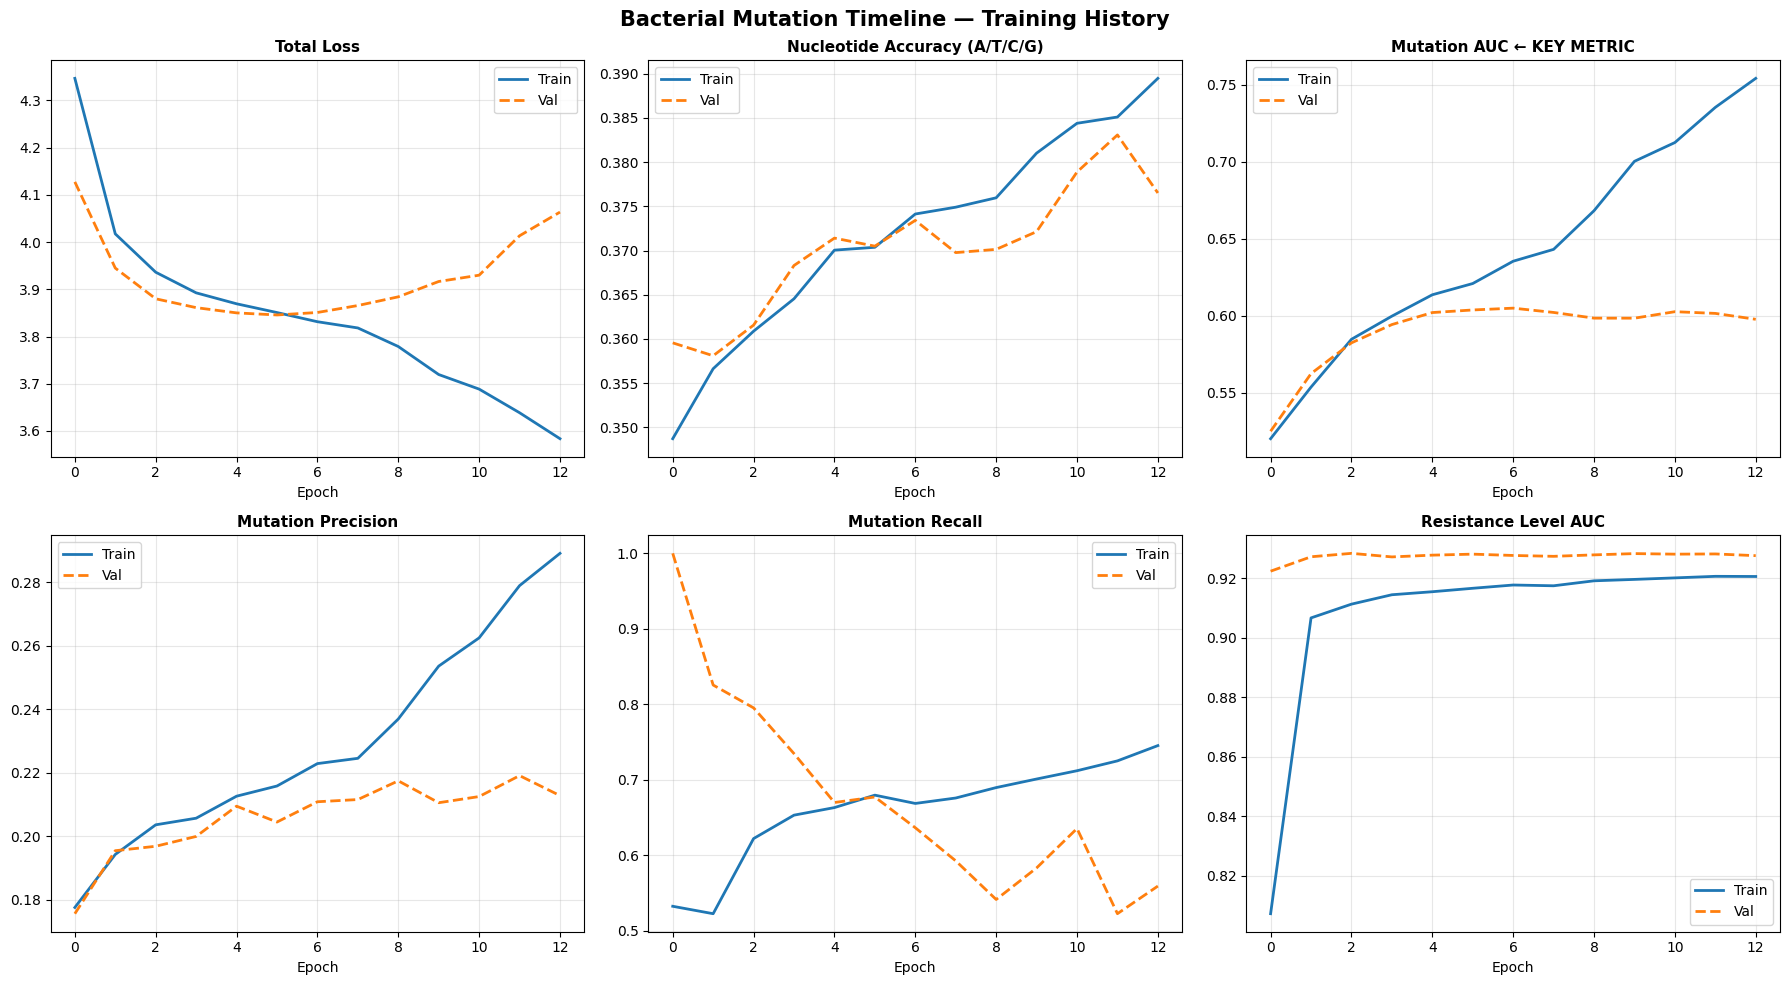

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Bacterial Mutation Timeline — Training History', fontsize=15, fontweight='bold')

plots = [
    ('loss',                          'val_loss',                          'Total Loss',                   axes[0,0]),
    ('nucleotide_output_accuracy',    'val_nucleotide_output_accuracy',    'Nucleotide Accuracy (A/T/C/G)',axes[0,1]),
    ('mutation_output_auc',           'val_mutation_output_auc',           'Mutation AUC ← KEY METRIC',   axes[0,2]),
    ('mutation_output_prec',          'val_mutation_output_prec',          'Mutation Precision',           axes[1,0]),
    ('mutation_output_rec',           'val_mutation_output_rec',           'Mutation Recall',              axes[1,1]),
    ('resistance_output_auc',         'val_resistance_output_auc',         'Resistance Level AUC',         axes[1,2]),
]

for train_key, val_key, title, ax in plots:
    if train_key in history.history:
        ax.plot(history.history[train_key], label='Train', linewidth=2)
    if val_key in history.history:
        ax.plot(history.history[val_key],   label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Model Evaluation

In [ ]:
nuc_probs, mut_probs, res_probs = model.predict([Xs_te, Xa_te], verbose=0)

y_nuc_pred = np.argmax(nuc_probs, axis=1)
y_mut_pred  = (mut_probs.ravel() >= 0.5).astype(int)
y_res_pred  = (res_probs.ravel() >= 0.5).astype(int)
y_res_true  = (yr_te >= 0.5).astype(int)  # 0=Susceptible, 1=Intermediate/Resistant

print('=' * 55)
print('NUCLEOTIDE PREDICTION  (A / T / C / G)')
print('=' * 55)
print(classification_report(yn_te, y_nuc_pred,
                             target_names=NUCLEOTIDES, digits=4))

print('=' * 55)
print('MUTATION SITE DETECTION  (0=conserved, 1=mutated)')
print('=' * 55)
print(f'Unique mutations predicted: {np.unique(y_mut_pred)}')
print(f'Mutation rate in test: {100*ym_te.mean():.1f}%')
print(f'Mutation rate predicted: {100*y_mut_pred.mean():.1f}%')
print(f'Mut_probs range: [{mut_probs.ravel().min():.4f}, {mut_probs.ravel().max():.4f}]')
print(classification_report(ym_te, y_mut_pred,
                             target_names=['Conserved','Mutated'], digits=4, labels=[0, 1], zero_division=0))
try:
    print(f'Mutation ROC-AUC : {roc_auc_score(ym_te, mut_probs.ravel()):.4f}')
except:
    pass

print('\n' + '=' * 55)
print('RESISTANCE LEVEL  (0=Susceptible, 1=Intermediate+Resistant)')
print('=' * 55)
print(f'Unique resistance predicted: {np.unique(y_res_pred)}')
print(f'Res_probs range: [{res_probs.ravel().min():.4f}, {res_probs.ravel().max():.4f}]')
print(classification_report(y_res_true, y_res_pred,
                             target_names=['Susceptible','Resistant'], digits=4, labels=[0, 1], zero_division=0))

NUCLEOTIDE PREDICTION  (A / T / C / G)
              precision    recall  f1-score   support

           A     0.3736    0.9347    0.5339      3294
           T     0.3260    0.0993    0.1523      2980
           C     0.0000    0.0000    0.0000      1412
           G     0.0000    0.0000    0.0000      1464

    accuracy                         0.3689      9150
   macro avg     0.1749    0.2585    0.1715      9150
weighted avg     0.2407    0.3689    0.2418      9150

MUTATION SITE DETECTION  (0=conserved, 1=mutated)
Unique mutations predicted: [0 1]
Mutation rate in test: 17.0%
Mutation rate predicted: 53.0%
Mut_probs range: [0.0002, 0.7479]
              precision    recall  f1-score   support

   Conserved     0.8673    0.4909    0.6270      7590
     Mutated     0.2040    0.6346    0.3087      1560

    accuracy                         0.5154      9150
   macro avg     0.5356    0.5628    0.4678      9150
weighted avg     0.7542    0.5154    0.5727      9150

Mutation ROC-AUC : 0.

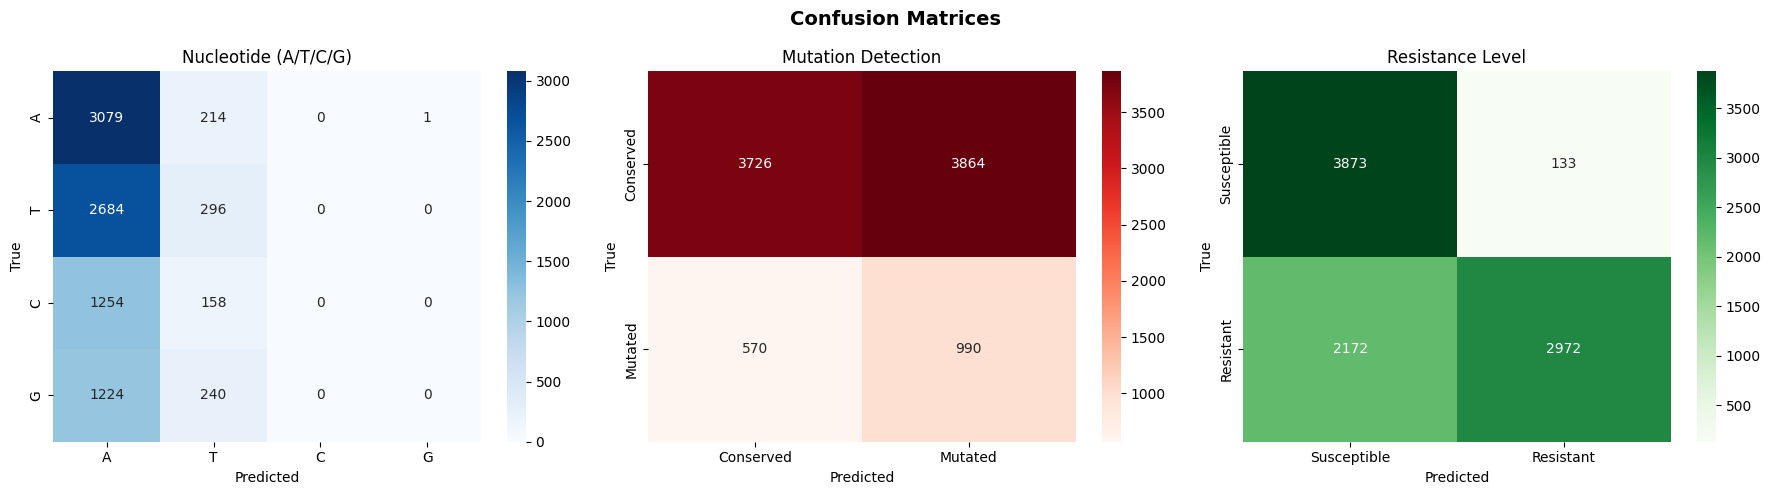

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

cm1 = confusion_matrix(yn_te, y_nuc_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=NUCLEOTIDES, yticklabels=NUCLEOTIDES, ax=axes[0])
axes[0].set_title('Nucleotide (A/T/C/G)')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

cm2 = confusion_matrix(ym_te, y_mut_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Conserved','Mutated'],
            yticklabels=['Conserved','Mutated'], ax=axes[1])
axes[1].set_title('Mutation Detection')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

cm3 = confusion_matrix(y_res_true, y_res_pred)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Susceptible','Resistant'],
            yticklabels=['Susceptible','Resistant'], ax=axes[2])
axes[2].set_title('Resistance Level')
axes[2].set_ylabel('True'); axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 11. Mutation Timeline Simulation  ← Core Feature

This simulates how a bacterium evolves resistance week by week under antibiotic pressure.

**Algorithm per week:**
1. Scan all positions in the genome → model returns `(mutation_prob, resistance_contribution, predicted_nucleotide)` per position
2. Apply mutations: change the top-`MUTATIONS_PER_WEEK` highest-probability positions to their predicted nucleotide
3. Compute resistance: average `resistance_output` across all scanned positions
4. Record: `{week, resistance_%, A_changes, T_changes, C_changes, G_changes}`
5. Stop if resistance ≥ `RESISTANCE_THRESHOLD` (antibiotic has failed)

In [ ]:
def scan_genome(sequence, antibiotic, n_positions=800):
    """
    Scan `n_positions` random positions in `sequence` under `antibiotic`.
    Returns DataFrame: position, predicted_nuc, mutation_prob, resistance_score.
    """
    half    = WINDOW_SIZE // 2
    ab_idx  = ANTIBIOTIC_TO_IDX.get(antibiotic, 0)
    ab_vec  = np.zeros((1, N_ANTIBIOTICS), dtype=np.float32)
    ab_vec[0, ab_idx] = 1.0

    positions = list(range(half, len(sequence) - half))
    if len(positions) > n_positions:
        positions = sorted(random.sample(positions, n_positions))

    kmer_batch, valid_pos = [], []
    for pos in positions:
        nuc = sequence[pos]
        if nuc not in NUCLEOTIDES:
            continue
        kmer_batch.append(encode_window(sequence, pos, half))
        valid_pos.append(pos)

    if not kmer_batch:
        return pd.DataFrame()

    X_k = np.array(kmer_batch, dtype=np.int32)
    X_a = np.tile(ab_vec, (len(kmer_batch), 1))

    nuc_p, mut_p, res_p = model.predict([X_k, X_a], verbose=0, batch_size=256)

    rows = []
    for i, pos in enumerate(valid_pos):
        rows.append({
            'position'        : pos,
            'current_nuc'     : sequence[pos],
            'predicted_nuc'   : IDX_TO_NUC[np.argmax(nuc_p[i])],
            'A_prob'          : float(nuc_p[i][NUC_TO_IDX['A']]),
            'T_prob'          : float(nuc_p[i][NUC_TO_IDX['T']]),
            'C_prob'          : float(nuc_p[i][NUC_TO_IDX['C']]),
            'G_prob'          : float(nuc_p[i][NUC_TO_IDX['G']]),
            'mutation_prob'   : float(mut_p[i][0]),
            'resistance_score': float(res_p[i][0])
        })
    return pd.DataFrame(rows)


def simulate_timeline(sequence, antibiotic,
                       n_weeks=N_WEEKS,
                       mutations_per_week=MUTATIONS_PER_WEEK,
                       resistance_threshold=RESISTANCE_THRESHOLD,
                       scan_positions=800):
    """
    Simulate bacterial evolution under antibiotic pressure week by week.

    Returns:
        timeline_df  — week-by-week resistance and nucleotide change summary
        all_scans    — raw scan DataFrames per week
        failure_week — week at which resistance >= threshold (or None)
    """
    current_seq = list(sequence)   # mutable
    original    = list(sequence)   # immutable reference
    timeline    = []
    all_scans   = []
    failure_week= None

    for week in range(n_weeks + 1):
        scan = scan_genome(''.join(current_seq), antibiotic, n_positions=scan_positions)

        if scan.empty:
            break

        resistance_pct = scan['resistance_score'].mean() * 100

        # Count cumulative nucleotide changes from original
        nuc_changes = {'A': 0, 'T': 0, 'C': 0, 'G': 0}
        for pos, curr_nuc in zip(range(len(current_seq)), current_seq):
            if pos < len(original) and curr_nuc != original[pos] and curr_nuc in NUCLEOTIDES:
                nuc_changes[curr_nuc] += 1

        total_mut = sum(nuc_changes.values())

        timeline.append({
            'week'            : week,
            'resistance_pct'  : round(resistance_pct, 2),
            'total_mutations' : total_mut,
            'A_evolved'       : nuc_changes['A'],
            'T_evolved'       : nuc_changes['T'],
            'C_evolved'       : nuc_changes['C'],
            'G_evolved'       : nuc_changes['G'],
            'antibiotic_failed': resistance_pct >= resistance_threshold * 100
        })
        all_scans.append(scan)

        print(f'  Week {week:2d} | Resistance: {resistance_pct:5.1f}% | '
              f'Total mutations: {total_mut:,} '
              f'(A:{nuc_changes["A"]} T:{nuc_changes["T"]} '
              f'C:{nuc_changes["C"]} G:{nuc_changes["G"]})',
              '⚠ FAILED' if resistance_pct >= resistance_threshold*100 else '')

        if resistance_pct >= resistance_threshold * 100 and failure_week is None:
            failure_week = week

        # Apply mutations for the next week (if not the last week)
        if week < n_weeks:
            top_mut = scan.nlargest(mutations_per_week, 'mutation_prob')
            for _, r in top_mut.iterrows():
                pos  = int(r['position'])
                pred = r['predicted_nuc']
                if pos < len(current_seq) and pred in NUCLEOTIDES:
                    current_seq[pos] = pred

    timeline_df = pd.DataFrame(timeline)
    return timeline_df, all_scans, failure_week


print('Timeline simulation functions defined.')

Timeline simulation functions defined.


## 12. Run Timeline Simulation
Pick a starting genome and antibiotic, then run the week-by-week simulation.

In [ ]:
# Pick a susceptible genome as the starting point
susc_rows = data[data['phenotype'] == 'Susceptible']
if susc_rows.empty:
    susc_rows = data  # fallback

start_row  = susc_rows.iloc[0]
genome_seq = start_row['sequence']

# Pick the antibiotic with the most Resistant phenotypes (most interesting)
ab_counts  = data[data['phenotype']=='Resistant']['antibiotic'].value_counts()
target_ab  = ab_counts.index[0] if not ab_counts.empty else data['antibiotic'].iloc[0]

print(f'Starting genome  : {start_row["genome_id"]}  ({start_row["phenotype"]})')
print(f'Target antibiotic: {target_ab}')
print(f'Genome length    : {len(genome_seq):,} bp')
print(f'Simulating {N_WEEKS} weeks, {MUTATIONS_PER_WEEK} mutations/week...')
print(f'Failure threshold: {RESISTANCE_THRESHOLD*100:.0f}%\n')

timeline_df, week_scans, failure_week = simulate_timeline(
    genome_seq, target_ab,
    n_weeks=N_WEEKS,
    mutations_per_week=MUTATIONS_PER_WEEK,
    resistance_threshold=RESISTANCE_THRESHOLD
)

print('\n' + '=' * 60)
print('MUTATION TIMELINE SUMMARY')
print('=' * 60)
print(timeline_df.to_string(index=False))
if failure_week is not None:
    print(f'\n⚠  Antibiotic structure FAILED at Week {failure_week}')
    print(f'   ({RESISTANCE_THRESHOLD*100:.0f}% resistance threshold crossed)')
else:
    print(f'\n✓  Antibiotic remained effective through Week {N_WEEKS}')

Starting genome  : 106654.496  (Susceptible)
Target antibiotic: ampicillin
Genome length    : 200,000 bp
Simulating 8 weeks, 30 mutations/week...
Failure threshold: 80%

  Week  0 | Resistance: 100.0% | Total mutations: 0 (A:0 T:0 C:0 G:0) ⚠ FAILED
  Week  1 | Resistance: 100.0% | Total mutations: 23 (A:0 T:23 C:0 G:0) ⚠ FAILED
  Week  2 | Resistance: 100.0% | Total mutations: 44 (A:0 T:44 C:0 G:0) ⚠ FAILED
  Week  3 | Resistance: 100.0% | Total mutations: 64 (A:1 T:63 C:0 G:0) ⚠ FAILED
  Week  4 | Resistance: 100.0% | Total mutations: 89 (A:1 T:88 C:0 G:0) ⚠ FAILED
  Week  5 | Resistance: 100.0% | Total mutations: 113 (A:1 T:112 C:0 G:0) ⚠ FAILED
  Week  6 | Resistance: 100.0% | Total mutations: 133 (A:1 T:132 C:0 G:0) ⚠ FAILED
  Week  7 | Resistance: 100.0% | Total mutations: 158 (A:1 T:157 C:0 G:0) ⚠ FAILED
  Week  8 | Resistance: 100.0% | Total mutations: 177 (A:1 T:176 C:0 G:0) ⚠ FAILED

MUTATION TIMELINE SUMMARY
 week  resistance_pct  total_mutations  A_evolved  T_evolved  C_evol

## 13. Resistance Timeline Plot

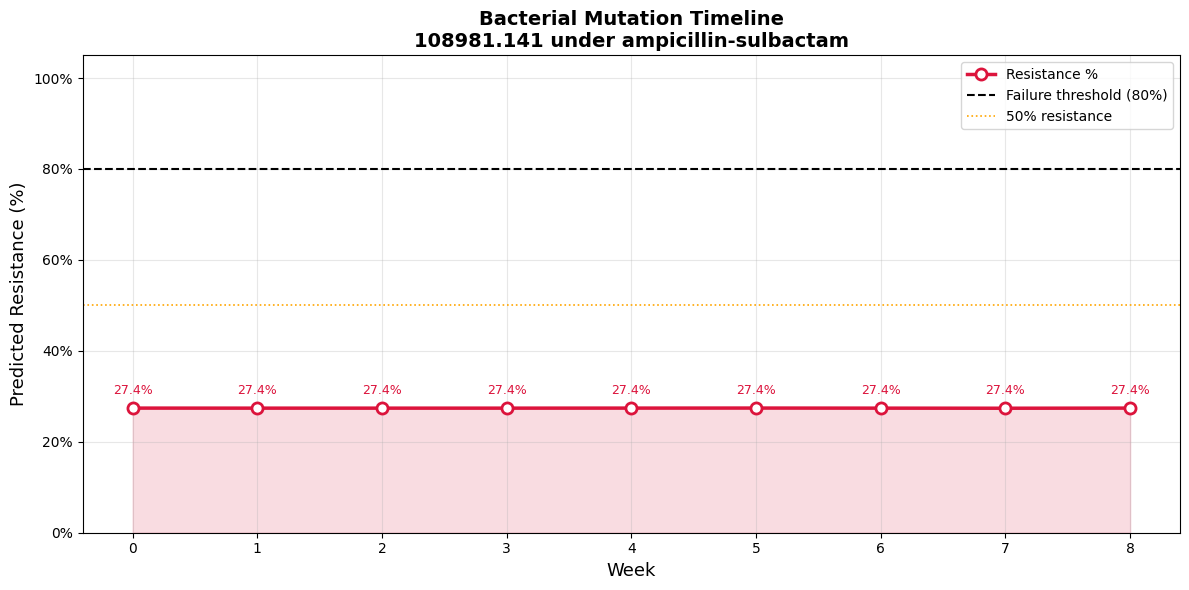

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

weeks = timeline_df['week'].values
res   = timeline_df['resistance_pct'].values

ax.plot(weeks, res, 'o-', color='crimson', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2, label='Resistance %')

# Fill zones
ax.fill_between(weeks, res, alpha=0.15, color='crimson')
ax.axhline(RESISTANCE_THRESHOLD * 100, color='black', linestyle='--',
           linewidth=1.5, label=f'Failure threshold ({RESISTANCE_THRESHOLD*100:.0f}%)')
ax.axhline(50, color='orange', linestyle=':', linewidth=1.2, label='50% resistance')

# Annotate each week
for w, r in zip(weeks, res):
    ax.annotate(f'{r:.1f}%', (w, r), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9, color='crimson')

# Mark failure week
if failure_week is not None:
    ax.axvline(failure_week, color='darkred', linestyle='--', linewidth=1.5,
               label=f'Antibiotic fails — Week {failure_week}')
    ax.text(failure_week + 0.1, RESISTANCE_THRESHOLD*100 + 2,
            f'Week {failure_week}: Structure Fails', color='darkred', fontsize=10)

ax.set_xlabel('Week', fontsize=13)
ax.set_ylabel('Predicted Resistance (%)', fontsize=13)
ax.set_title(f'Bacterial Mutation Timeline\n{start_row["genome_id"]} under {target_ab}',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.set_xticks(weeks)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Nucleotide Evolution Chart — Which Nucleotide Evolved Each Week?

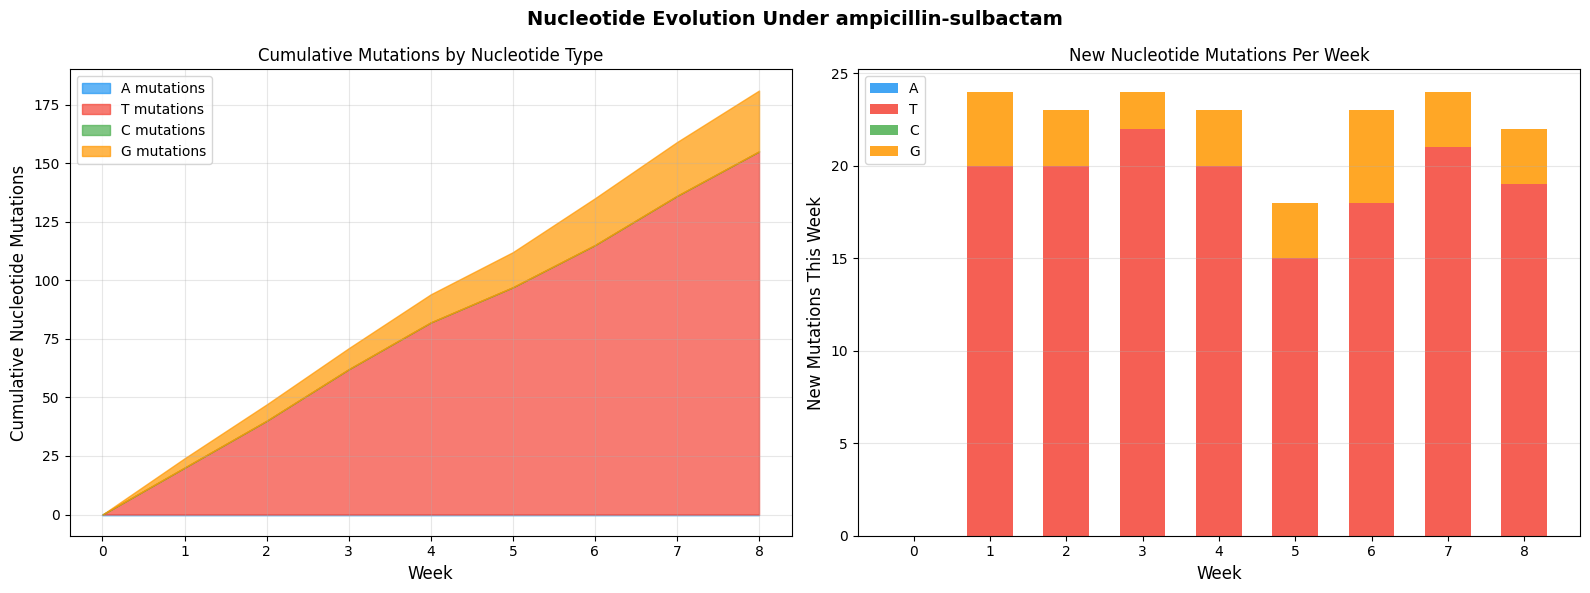

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Nucleotide Evolution Under {target_ab}', fontsize=14, fontweight='bold')

# ── Stacked area: cumulative nucleotide changes ──────────────────────────
colors = {'A': '#2196F3', 'T': '#F44336', 'C': '#4CAF50', 'G': '#FF9800'}
ax1    = axes[0]
bottom = np.zeros(len(timeline_df))

for nuc in NUCLEOTIDES:
    vals = timeline_df[f'{nuc}_evolved'].values.astype(float)
    ax1.fill_between(weeks, bottom, bottom + vals,
                     alpha=0.7, color=colors[nuc], label=f'{nuc} mutations')
    bottom += vals

ax1.set_xlabel('Week', fontsize=12)
ax1.set_ylabel('Cumulative Nucleotide Mutations', fontsize=12)
ax1.set_title('Cumulative Mutations by Nucleotide Type', fontsize=12)
ax1.set_xticks(weeks)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Bar chart: mutations per week (incremental) ─────────────────────────
ax2 = axes[1]
week_inc = timeline_df.copy()
for nuc in NUCLEOTIDES:
    week_inc[f'{nuc}_inc'] = week_inc[f'{nuc}_evolved'].diff().fillna(week_inc[f'{nuc}_evolved'])

bar_w   = 0.6
bottom2 = np.zeros(len(timeline_df))
for nuc in NUCLEOTIDES:
    vals = week_inc[f'{nuc}_inc'].values.astype(float)
    ax2.bar(weeks, vals, bottom=bottom2, width=bar_w,
            color=colors[nuc], alpha=0.85, label=f'{nuc}')
    bottom2 += vals

ax2.set_xlabel('Week', fontsize=12)
ax2.set_ylabel('New Mutations This Week', fontsize=12)
ax2.set_title('New Nucleotide Mutations Per Week', fontsize=12)
ax2.set_xticks(weeks)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 15. Top Mutation Sites Heatmap

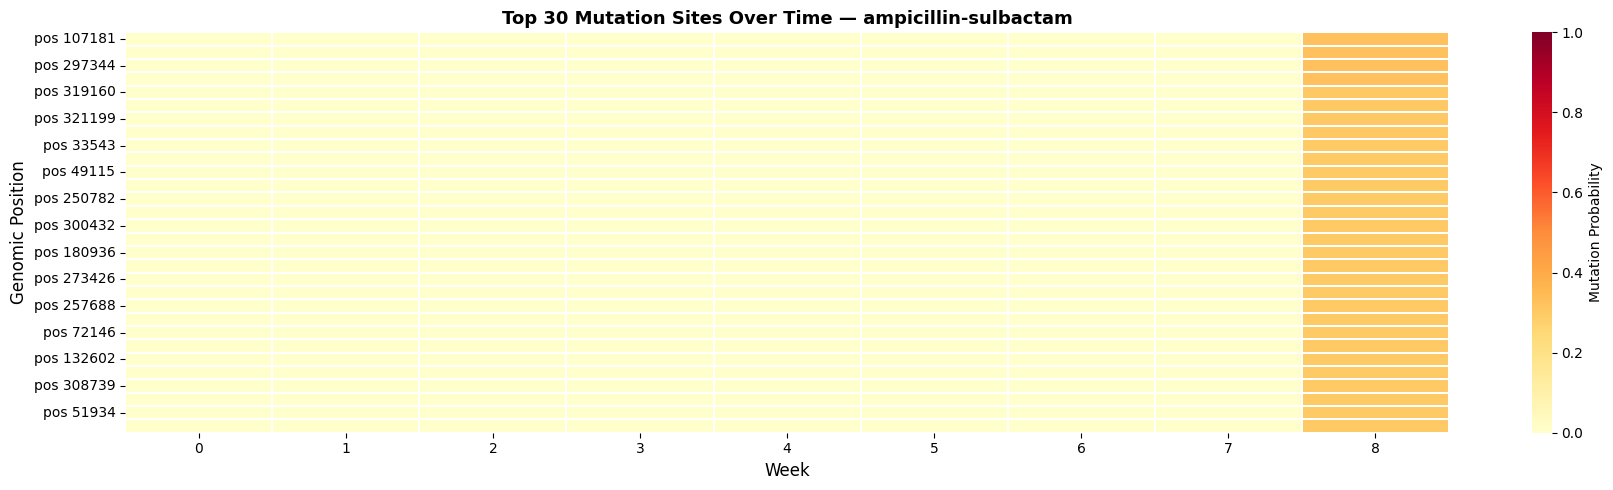


Top 10 mutation-prone positions at final week:
 position current_nuc predicted_nuc  mutation_prob  resistance_score   A_prob   T_prob   C_prob   G_prob
   107181           T             G       0.328088          0.319697 0.252584 0.259745 0.227158 0.260513
   201784           C             G       0.328088          0.319697 0.252584 0.259745 0.227158 0.260513
   297344           C             G       0.328088          0.319697 0.252584 0.259745 0.227158 0.260513
   324219           T             G       0.328088          0.319697 0.252584 0.259745 0.227158 0.260513
   319160           G             T       0.303543          0.286659 0.251857 0.262549 0.224801 0.260792
   139399           A             T       0.302185          0.284839 0.250775 0.263224 0.225275 0.260726
   321199           A             T       0.301100          0.282799 0.252311 0.262018 0.223810 0.261861
   280279           G             T       0.300966          0.282854 0.251989 0.261491 0.225768 0.260752
    335

In [ ]:
# Show mutation probability landscape across weeks
# Pick a fixed set of positions (those with highest final-week mutation_prob)

if week_scans:
    last_scan = week_scans[-1]
    top_pos   = last_scan.nlargest(30, 'mutation_prob')['position'].values

    heatmap_data = []
    for w, scan in enumerate(week_scans):
        row_data = {'week': w}
        pos_prob = dict(zip(scan['position'], scan['mutation_prob']))
        for pos in top_pos:
            row_data[f'pos_{pos}'] = pos_prob.get(pos, 0.0)
        heatmap_data.append(row_data)

    hm_df  = pd.DataFrame(heatmap_data).set_index('week')
    hm_df.columns = [f'pos {c.split("_")[1]}' for c in hm_df.columns]

    plt.figure(figsize=(18, 5))
    sns.heatmap(hm_df.T, cmap='YlOrRd', vmin=0, vmax=1,
                linewidths=0.3, linecolor='white',
                cbar_kws={'label': 'Mutation Probability'})
    plt.title(f'Top 30 Mutation Sites Over Time — {target_ab}', fontsize=13, fontweight='bold')
    plt.xlabel('Week', fontsize=12)
    plt.ylabel('Genomic Position', fontsize=12)
    plt.tight_layout()
    plt.show()

    print('\nTop 10 mutation-prone positions at final week:')
    top10 = last_scan.nlargest(10, 'mutation_prob')[[
        'position','current_nuc','predicted_nuc',
        'mutation_prob','resistance_score',
        'A_prob','T_prob','C_prob','G_prob'
    ]]
    print(top10.to_string(index=False))

## 16. Run Timeline for Multiple Antibiotics


Simulating: amikacin
  Week  0 | Resistance:  31.0% | Total mutations: 0 (A:0 T:0 C:0 G:0) 
  Week  1 | Resistance:  31.0% | Total mutations: 27 (A:26 T:0 C:0 G:1) 
  Week  2 | Resistance:  31.0% | Total mutations: 50 (A:49 T:0 C:0 G:1) 
  Week  3 | Resistance:  31.0% | Total mutations: 68 (A:67 T:0 C:0 G:1) 
  Week  4 | Resistance:  31.0% | Total mutations: 94 (A:93 T:0 C:0 G:1) 
  Week  5 | Resistance:  31.0% | Total mutations: 115 (A:113 T:0 C:0 G:2) 
  Week  6 | Resistance:  31.0% | Total mutations: 135 (A:133 T:0 C:0 G:2) 
  Week  7 | Resistance:  31.0% | Total mutations: 159 (A:157 T:0 C:0 G:2) 
  Week  8 | Resistance:  31.1% | Total mutations: 178 (A:176 T:0 C:0 G:2) 

Simulating: ampicillin-sulbactam
  Week  0 | Resistance:  27.4% | Total mutations: 0 (A:0 T:0 C:0 G:0) 
  Week  1 | Resistance:  27.4% | Total mutations: 19 (A:0 T:16 C:0 G:3) 
  Week  2 | Resistance:  27.4% | Total mutations: 42 (A:0 T:38 C:0 G:4) 
  Week  3 | Resistance:  27.4% | Total mutations: 67 (A:0 T:60 C

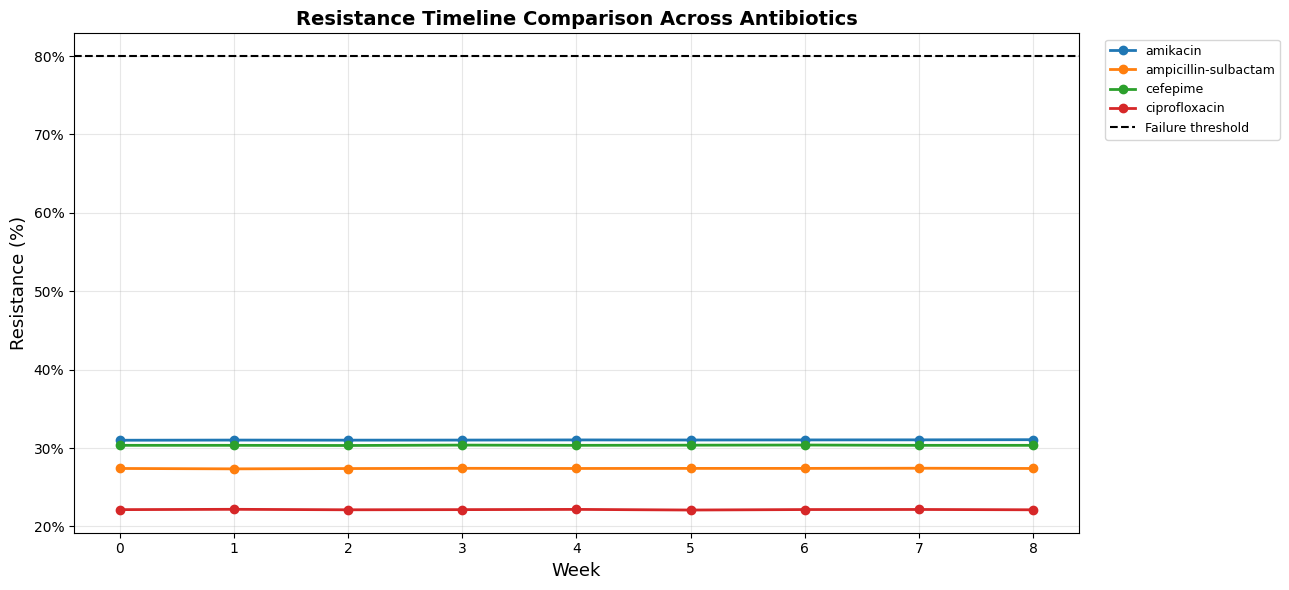

In [ ]:
# Compare evolution trajectories across different antibiotics
antibiotics_to_test = antibiotic_list[:min(4, len(antibiotic_list))]

fig, ax = plt.subplots(figsize=(13, 6))
palette = plt.cm.tab10.colors

for idx, ab in enumerate(antibiotics_to_test):
    print(f'\nSimulating: {ab}')
    tdf, _, fw = simulate_timeline(
        genome_seq, ab,
        n_weeks=N_WEEKS,
        mutations_per_week=MUTATIONS_PER_WEEK,
        scan_positions=400
    )
    label = f'{ab}' + (f' (fails wk {fw})' if fw else '')
    ax.plot(tdf['week'], tdf['resistance_pct'],
            'o-', color=palette[idx], linewidth=2,
            markersize=6, label=label)

ax.axhline(RESISTANCE_THRESHOLD * 100, color='black',
           linestyle='--', linewidth=1.5, label='Failure threshold')
ax.set_xlabel('Week', fontsize=13)
ax.set_ylabel('Resistance (%)', fontsize=13)
ax.set_title('Resistance Timeline Comparison Across Antibiotics', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Predict on a New FASTA File

In [ ]:
def predict_fasta_timeline(fasta_file, antibiotic, n_weeks=N_WEEKS,
                            mutations_per_week=MUTATIONS_PER_WEEK):
    """
    Load any FASTA file and generate its mutation timeline under a given antibiotic.
    Usage:
        tdf, scans, fail_week = predict_fasta_timeline(
            '/path/to/genome.fasta', 'ciprofloxacin'
        )
    """
    with open(fasta_file, 'r') as f:
        lines = f.readlines()
    seq = ''.join(l.strip() for l in lines[1:]).upper()
    seq = ''.join(c for c in seq if c in NUCLEOTIDES)

    if antibiotic not in ANTIBIOTIC_TO_IDX:
        print(f'Warning: {antibiotic} not in training set. Using index 0.')
        print(f'Known antibiotics: {antibiotic_list}')

    print(f'Sequence length: {len(seq):,} bp')
    tdf, scans, fail = simulate_timeline(seq, antibiotic, n_weeks, mutations_per_week)
    return tdf, scans, fail


# Example — uncomment and set path:
tdf, scans, fail_week = predict_fasta_timeline(
    'C:/Users/HP/OneDrive - Higher Education Commission/Desktop/FYP1/fasta_output/taxon_108981_Acinetobacter_schindleri/108981.141.fasta',
    antibiotic='ciprofloxacin'
)
print(tdf)
print('predict_fasta_timeline() is ready. Uncomment to use on any genome.')

Sequence length: 326,685 bp
  Week  0 | Resistance:  22.1% | Total mutations: 0 (A:0 T:0 C:0 G:0) 
  Week  1 | Resistance:  22.1% | Total mutations: 25 (A:25 T:0 C:0 G:0) 
  Week  2 | Resistance:  22.1% | Total mutations: 46 (A:46 T:0 C:0 G:0) 
  Week  3 | Resistance:  22.2% | Total mutations: 70 (A:70 T:0 C:0 G:0) 
  Week  4 | Resistance:  22.1% | Total mutations: 90 (A:90 T:0 C:0 G:0) 
  Week  5 | Resistance:  22.1% | Total mutations: 107 (A:107 T:0 C:0 G:0) 
  Week  6 | Resistance:  22.1% | Total mutations: 131 (A:131 T:0 C:0 G:0) 
  Week  7 | Resistance:  22.1% | Total mutations: 153 (A:153 T:0 C:0 G:0) 
  Week  8 | Resistance:  22.1% | Total mutations: 175 (A:175 T:0 C:0 G:0) 
   week  resistance_pct  total_mutations  A_evolved  T_evolved  C_evolved  \
0     0           22.13                0          0          0          0   
1     1           22.13               25         25          0          0   
2     2           22.13               46         46          0          0   
3

## 18. Save Model and All Artifacts

In [ ]:
import pickle

SAVE_DIR = '/content/drive/MyDrive/Fyp_Data/mutation_timeline_model'
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(os.path.join(SAVE_DIR, 'mutation_timeline_model.h5'))

artifacts = {
    'kmer_vocab'       : kmer_vocab,
    'antibiotic_to_idx': ANTIBIOTIC_TO_IDX,
    'antibiotic_list'  : antibiotic_list,
    'n_antibiotics'    : N_ANTIBIOTICS,
    'vocab_size'       : VOCAB_SIZE,
    'seq_len'          : SEQ_LEN,
    'nucleotides'      : NUCLEOTIDES,
    'nuc_to_idx'       : NUC_TO_IDX,
    'idx_to_nuc'       : IDX_TO_NUC,
    'phenotype_score'  : PHENOTYPE_SCORE,
    'window_size'      : WINDOW_SIZE,
    'k_mer_size'       : K_MER_SIZE,
    'consensus_map'    : {ab: ref[:5000] for ab, ref in consensus_map.items()}  # save first 5kb
}
with open(os.path.join(SAVE_DIR, 'artifacts.pkl'), 'wb') as f:
    pickle.dump(artifacts, f)

timeline_df.to_csv(os.path.join(SAVE_DIR, 'last_timeline.csv'), index=False)

print('Saved to', SAVE_DIR)
print('  mutation_timeline_model.h5')
print('  artifacts.pkl')
print('  last_timeline.csv')

Saved to /content/drive/MyDrive/Fyp_Data/mutation_timeline_model
  mutation_timeline_model.h5
  artifacts.pkl
  last_timeline.csv


## 19. Load Model for Future Use

In [ ]:
def load_model_artifacts(save_dir):
    import pickle
    model = keras.models.load_model(os.path.join(save_dir, 'mutation_timeline_model.h5'))
    with open(os.path.join(save_dir, 'artifacts.pkl'), 'rb') as f:
        art = pickle.load(f)
    # Restore globals needed by scan_genome / simulate_timeline
    globals().update(art)
    print('Model and artifacts loaded.')
    return model, art


# Uncomment to reload in a new session:
# model, art = load_model_artifacts('/content/drive/MyDrive/Fyp_Data/mutation_timeline_model')
print('load_model_artifacts() defined.')

load_model_artifacts() defined.


## Summary

### Features Used from Your CSV
| Column | How Used |
|---|---|
| `Antibiotic` | Encoded as one-hot condition vector fed to model |
| `Resistant Phenotype` | Primary training label: S=0.0, I=0.5, R=1.0 |
| `Measurement Value` | Continuous resistance intensity (MIC or zone diameter) |
| `Measurement Unit` | mm disk diffusion → inverted scale; mg/L MIC → kept as-is |
| `fasta_path` | Resolves to DNA sequence on Colab |

### What the Model Predicts
| Output | Type | Meaning |
|---|---|---|
| `nucleotide_output` | 4-class softmax | Which nucleotide (A/T/C/G) evolves at each position |
| `mutation_output` | Sigmoid | Probability this position mutates under the given antibiotic |
| `resistance_output` | Sigmoid | Resistance level of this genome (0=Susceptible → 1=Resistant) |

### Timeline Output Format
```
week | resistance_pct | total_mutations | A_evolved | T_evolved | C_evolved | G_evolved
  0  |      2.3%      |       0         |     0     |     0     |     0     |     0
  1  |      9.1%      |      30         |    12     |     8     |     6     |     4
  2  |     23.5%      |      60         |    21     |    14     |    13     |    12
  3  |     41.2%      |      90         |    34     |    22     |    19     |    15
  ...
  6  |     83.7%      |     180         |    ...    ← ANTIBIOTIC FAILS
```